# 12-3 양자화로 LLM 가볍게 돌리기

본 노트북은 12-3절 본문 예제 [코드 12-14]~[코드 12-17]을 모아 위에서 아래로
실행한다. bitsandbytes로 Bllossom-3B를 4비트 양자화해 추론에 사용하고, 이어서
양자화 모델에 LoRA 어댑터만 학습하는 QLoRA로 자연어를 함수 호출 JSON으로
변환하는 모델(모델 17: AI 입력 생성기)을 만든다.

**실행 환경 안내** - bitsandbytes 양자화는 NVIDIA GPU(CUDA)를 전제로 한다.
8GB 이상 VRAM을 갖춘 NVIDIA GPU가 필요하며, 저자 환경(RTX 4070 SUPER 12GB)에서
학습·실행에 무리가 없음을 확인했다. NVIDIA GPU가 없으면 구글 코랩 무료 GPU
티어를 사용한다.

**이 장의 코드 컨벤션 알림** - 12장은 허깅페이스 라이브러리를 중심 주제로
다루므로, `MODEL_NAME` 등 상수 표기는 공통 컨벤션을 따르지만 `model`,
`tokenizer` 등 객체명은 HF 통용 표기를 그대로 사용한다. 양자화 자료형
(`torch.float16` 등)과 LoRA 인자(`r`, `lora_alpha`, `target_modules`)도
라이브러리 표기를 그대로 쓴다.

다루는 내용
- 본문 비공개 항목: 답변 생성 헬퍼, 함수 스키마/시스템 프롬프트, 학습·평가
  데이터 합성, -100 마스킹 토크나이즈, 채점 함수 (모두 `# 참고` 셀)
- [코드 12-14] 양자화 설정 객체를 만들고 4비트 양자화 모델 불러오기
- [코드 12-15] QLoRA 모델 준비
- [코드 12-16] QLoRA 학습 엔진 생성 및 학습 실행
- [코드 12-17] LoRA 어댑터 계층 활성화/비활성화별 모델 평가

> 사용 모델: Bllossom/llama-3.2-Korean-Bllossom-3B (Llama 3.2 커뮤니티 라이선스).


In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q accelerate bitsandbytes peft transformers


In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

device = common.get_device()

CUDA를 사용합니다.


In [ ]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

# # 참고 - 라이브러리 import 와 시드 고정
# import gc          # 모델 메모리 해제 시 명시적으로 GC를 돌리기 위해
# import json
# import random      # 데이터 합성 시 슬롯·템플릿 무작위 선택에 사용
# import re
# import warnings

# import numpy as np
# import torch
# from transformers import (
#     AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
# )

# warnings.filterwarnings('ignore')

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)


## 참고 - 답변 생성 헬퍼 generate_with_llama()

12-1절 [코드 12-7]을 모델·토크나이저를 인자로 받는 함수로 묶었다. 양자화 전후
모델의 답변을 같은 방식으로 받기 위해 사용한다.


In [4]:
# 참고 - 답변 생성 헬퍼 (12-1절 [코드 12-7]을 함수로 묶은 것)
def generate_with_llama(prompt, model, tokenizer, max_new_tokens=256):
    # LLaMA 계열은 종료 토큰이 두 가지다 (<|end_of_text|>, <|eot_id|>).
    terminators = [
        tokenizer.convert_tokens_to_ids('<|end_of_text|>'),
        tokenizer.convert_tokens_to_ids('<|eot_id|>'),
    ]
    messages = [
        {'role': 'system',
         'content': '당신은 한국어를 사용하는 친절한 AI 친구입니다.'},
        {'role': 'user', 'content': prompt},
    ]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors='pt', return_dict=False,
    ).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            eos_token_id=terminators,
            do_sample=True, temperature=0.6, top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    llm_generated = output_ids[0][input_ids.shape[-1]:]
    return tokenizer.decode(llm_generated, skip_special_tokens=True)


def gpu_memory_mb():
    """현재 PyTorch가 GPU에 할당한 메모리를 MB 단위로 반환."""
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.memory_allocated() / 1024 / 1024


## [코드 12-14] 양자화 설정 객체를 만들고 4비트 양자화 모델 불러오기

`[코드 12-2]`의 모델 로드에 양자화 설정 객체(`BitsAndBytesConfig`)만 추가하면
4비트 양자화 모델을 불러온다. `device_map='auto'`로 자동 배치되므로 양자화
모델에는 `.to(device)`를 적용하지 않는다.


In [ ]:
###############################################################################
# 코드 12-14 - 양자화 설정 객체를 만들고 4비트 양자화 모델 불러오기
###############################################################################
MODEL_NAME = 'Bllossom/llama-3.2-Korean-Bllossom-3B'

# 4비트 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # 4비트로 모델 가중치 로드
    bnb_4bit_quant_type='nf4',              # NF4 형식 사용
    bnb_4bit_compute_dtype=torch.float16,   # 행렬곱 계산은 FP16으로
    bnb_4bit_use_double_quant=True,         # 양자화 상수도 한 번 더 양자화
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_q = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config,
    device_map='auto',                      # 사용 가능한 장치에 자동 배치
)

# 양자화 모델을 불러온 직후의 가속기 메모리를 측정해 두었다가 뒤에서 비교한다
q_memory_mb = gpu_memory_mb()
print(f'양자화 모델 로딩 후 GPU 메모리: {q_memory_mb:.0f} MB')


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

양자화 모델 로딩 후 GPU 메모리: 2139 MB


### 양자화 전후의 메모리 사용량과 답변 비교

`torch.cuda.memory_allocated()`로 메모리를 비교하고, 양자화하지 않은 FP16
모델과 답변을 비교한다. 호출할 때마다 답변이 달라지므로 한 예시만 본다.


In [6]:
# 참고 - 양자화(NF4)/비양자화(FP16) 모델의 메모리와 답변 비교
prompt = '대규모 언어 모델을 적은 자원으로 다루는 방법을 알려 줘.'

print('--- 양자화 적용(NF4) 모델 답변 ---')
print(generate_with_llama(prompt, model_q, tokenizer))

# FP16 비교군 적재를 위해 양자화 모델을 잠시 비운다
del model_q
gc.collect()
torch.cuda.empty_cache()

# 양자화 없이 불러온 비교군 (FP16)
model_fp = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16,
).to(device)
fp_memory_mb = gpu_memory_mb()

print(f'\n양자화 모델 메모리   : {q_memory_mb:.0f} MB')
print(f'비양자화(FP16) 메모리: {fp_memory_mb:.0f} MB')
print('\n--- 양자화 미적용(FP16) 모델 답변 ---')
print(generate_with_llama(prompt, model_fp, tokenizer))

# 비교가 끝나면 FP16 모델은 해제한다 (QLoRA 학습용 메모리 확보)
del model_fp
gc.collect()
torch.cuda.empty_cache()
print(f'\n해제 후 GPU 메모리: {gpu_memory_mb():.0f} MB')


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


--- 양자화 적용(NF4) 모델 답변 ---


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


대규모 언어 모델을 적은 자원으로 다루는 방법에는 여러 가지가 있습니다. 아래는 몇 가지 방법입니다.

1. **가속도**: 대규모 언어 모델은 매우 가속적인 성능을 제공합니다. 따라서, CPU와 GPU의 가속성을 높이면 모델의 성능을 크게 향상시킬 수 있습니다. 예를 들어, NVIDIA의 GeForce RTX 3080 GPU나 AMD의 Radeon RX 6800 XT GPU를 사용하면 성능을 크게 향상시킬 수 있습니다.

2. **메모리**: 대규모 언어 모델은 매우 많은 메모리를 필요로합니다. 따라서, 고성능 메모리(예: DDR5 RAM)를 사용하면 성능을 향상시킬 수 있습니다.

3. **네트워크**: 대규모 언어 모델은 네트워크를 통해 데이터를 전송해야 합니다. 따라서, 고성능 네트워크(예: 10GbE 네트워크)를 사용하면 성능을 향상시킬 수 있습니다.

4. ** cooler**: 대규모 언어 모델은 매우 높은 전력 소모를 요구합니다. 따라서, 고성능 쿨러(예


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]


양자화 모델 메모리   : 2139 MB
비양자화(FP16) 메모리: 6136 MB

--- 양자화 미적용(FP16) 모델 답변 ---
대규모 언어 모델을 적은 자원으로 다루는 방법은 여러 가지가 있습니다. 아래는 그 중 일부입니다:

1. **모델 크기 조정**: 대규모 언어 모델은 매우 큰 크기를 가지고 있습니다. 이를 줄이면 자원 사용량을 줄일 수 있습니다. 예를 들어, LLaMA, T5와 같은 모델은 대규모 언어 모델을 더 적은 크기로 조정하여 사용할 수 있습니다.

2. **모델 추론 최적화**: 모델을 최적화하여 더 빠른 추론을 수행할 수 있습니다. 예를 들어, 메모리 사용량을 줄이기 위해 모델의 추론을 최적화하는 기술이 있습니다.

3. **분산 추론**: 여러 기계ARNING 장치를 사용하여 모델의 추론을 분산시켜 자원 사용량을 줄일 수 있습니다. 예를 들어, Distributed Training을 통해 모델의 추론을 여러 기계ARNING 장치에서 분산시킬 수 있습니다.

4. **모델 최적화**: 모델의 가중치를 최적화하여 더 적은 자원을 사용할 수 있습니다. 예를 들어, Weight Pruning을 통해 모델의 가중

해제 후 GPU 메모리: 8 MB


## 참고 - 함수 스키마와 시스템 프롬프트 정의

QLoRA로 풀 문제(모델 17)는 사용자 발화를 함수 호출 JSON으로 변환하는 작업이다.
함수 7개를 한 딕셔너리(`FUNCTIONS`)로 묶고, 이를 사람이 읽을 수 있는 시스템
프롬프트로 변환한다. 이 시스템 프롬프트는 학습과 평가에서 동일하게 쓴다.


In [7]:
# 참고 - 함수 스키마와 시스템 프롬프트 정의
# 함수 스키마: 모델이 골라야 할 함수 7개를 한 dict로 묶는다.
FUNCTIONS = {
    'create_event': {'desc': '캘린더에 일정 추가',
                     'required': ['date', 'time', 'title']},
    'set_reminder': {'desc': '특정 시각에 알림',
                     'required': ['time', 'message']},
    'get_weather':  {'desc': '도시 날씨 조회',
                     'required': ['city'], 'optional': ['date']},
    'send_message': {'desc': '특정 사람에게 메시지 전송',
                     'required': ['recipient', 'content']},
    'play_music':   {'desc': '음악 재생',
                     'required': ['query']},
    'set_alarm':    {'desc': '알람 설정',
                     'required': ['time'], 'optional': ['label']},
    'search_web':   {'desc': '웹 검색',
                     'required': ['query']},
}


def build_system_prompt():
    """FUNCTIONS dict를 시스템 프롬프트 문자열로 변환한다."""
    lines = [
        '당신은 사용자 요청을 함수 호출 JSON으로 변환하는 어시스턴트입니다.',
        '응답은 반드시 단 하나의 JSON 객체만 출력합니다. '
        '설명·인사·줄바꿈을 포함하지 않습니다.',
        '',
        '사용 가능한 함수:',
    ]
    for name, spec in FUNCTIONS.items():
        args = ', '.join(spec['required'])
        if 'optional' in spec:
            args += ', ' + ', '.join(f'{a}?' for a in spec['optional'])
        lines.append(f'- {name}({args}): {spec["desc"]}')
    lines.append('')
    lines.append('응답 형식: {"function": "함수명", "args": {"key": "value", ...}}')
    return '\n'.join(lines)


SYSTEM_PROMPT = build_system_prompt()
print(SYSTEM_PROMPT)


당신은 사용자 요청을 함수 호출 JSON으로 변환하는 어시스턴트입니다.
응답은 반드시 단 하나의 JSON 객체만 출력합니다. 설명·인사·줄바꿈을 포함하지 않습니다.

사용 가능한 함수:
- create_event(date, time, title): 캘린더에 일정 추가
- set_reminder(time, message): 특정 시각에 알림
- get_weather(city, date?): 도시 날씨 조회
- send_message(recipient, content): 특정 사람에게 메시지 전송
- play_music(query): 음악 재생
- set_alarm(time, label?): 알람 설정
- search_web(query): 웹 검색

응답 형식: {"function": "함수명", "args": {"key": "value", ...}}


## 참고 - 학습·평가 데이터 합성

함수별 표면 표현 템플릿과 슬롯 풀(시각·도시·인물·곡명 등)을 조합해 (사용자 발화,
정답 JSON) 쌍을 만든다. 학습과 평가 템플릿을 분리해, 평가 발화는 학습에서 본 적
없는 표현이 되도록 한다. 함수 7개로 훈련 154건(7×22), 평가 21건(7×3)을 만든다.


In [8]:
# 참고 - 함수 호출 학습·평가 데이터 합성
# 슬롯 풀: 각 인자 자리에 들어갈 후보 값들
TIMES = ['오전 7시', '오전 9시', '오전 10시 30분', '오전 11시',
         '오후 1시', '오후 2시 15분', '오후 3시', '오후 5시',
         '저녁 7시', '저녁 8시 30분', '밤 10시', '밤 11시']
DATES = ['오늘', '내일', '모레', '글피', '이번 주 토요일',
         '다음 주 월요일', '다음 주 금요일', '5월 28일', '6월 3일', '6월 15일']
CITIES = ['서울', '부산', '대구', '인천', '광주',
          '대전', '울산', '제주', '강릉', '전주']
PEOPLE = ['김 부장님', '이 과장님', '박 대리', '최 팀장님',
          '엄마', '아빠', '동생', '수진이', '준호', '지민이']
EVENTS = ['팀 회의', '점심 약속', '치과 예약', '저녁 식사',
          '발표 준비', '운동', '독서 모임', '병원 진료']
MESSAGES_REMIND = ['회의 자료 챙기기', '약 먹기', '우산 챙기기',
                   '카드 결제 확인', '엄마한테 전화하기', '커피 사 오기']
SONGS = ['아이유 신곡', '오아시스의 Wonderwall', '클래식 피아노 음악',
         '잔잔한 재즈', 'BTS Dynamite', '뉴진스 노래', '비 오는 날 음악']
QUERIES = ['파이썬 데코레이터 사용법', '제주도 흑돼지 맛집', '오늘 환율 정보',
           '내일 야구 경기 결과', '서울 카페 추천', '딥러닝 기초 강의',
           '리눅스 셸 명령어']
MSG_CONTENTS = ['오늘 회의 좀 늦을 것 같아', '저녁 같이 먹을래?',
                '내일 일정 변경 가능?', '주말에 시간 어때?',
                '확인 부탁드립니다', '자료 받았습니다 감사합니다']
ALARM_LABELS = ['기상', '약 복용', '회의 알림', '운동 시작', '저녁 약속']

# 학습용 템플릿: 함수당 4종의 표면 표현
TRAIN_TEMPLATES = {
    'create_event': ['{date} {time}에 "{title}" 일정 잡아 줘',
                     '{date} {time} {title} 일정 추가해 줘',
                     '캘린더에 {date} {time}, {title} 등록해 줘',
                     '{title}을 {date} {time}에 일정으로 넣어 줘'],
    'set_reminder': ['{time}에 "{message}" 알림 보내 줘',
                     '{time}에 {message} 잊지 않게 알려 줘',
                     '{message} 알람 {time}에 맞춰 줘',
                     '{time}이 되면 {message} 알려 주세요'],
    'get_weather': ['{city} 날씨 알려 줘', '{date} {city} 날씨 어때?',
                    '{city}의 {date} 날씨가 궁금해', '{date} {city} 비 오나?'],
    'send_message': ['{recipient}한테 "{content}" 라고 메시지 보내 줘',
                     '{recipient}에게 {content} 전해 줘',
                     '{recipient}한테 메시지 보낼래: {content}',
                     '{content}이라고 {recipient}에게 전송해 줘'],
    'play_music': ['{query} 틀어 줘', '{query} 재생해 줘',
                   '{query} 좀 들려줘', '{query} 듣고 싶어'],
    'set_alarm': ['{time}에 알람 맞춰 줘', '{time}에 {label} 알람 설정해 줘',
                  '내일 {time} 알람 부탁해', '{time}에 {label} 깨워 줘'],
    'search_web': ['{query} 검색해 줘', '{query} 찾아 줘',
                   '{query} 정보 알아봐 줘', '{query}에 대해 검색해 봐'],
}

# 평가용 템플릿: 학습과 겹치지 않는 별개 표현
EVAL_TEMPLATES = {
    'create_event': ['{date} {time}부터 {title} 잡아 둘래?',
                     '이번에 {date} {time}에 {title} 있는데 캘린더 부탁해'],
    'set_reminder': ['{time}이 되면 {message} 알리도록 해 줘',
                     '나 {time}에 {message} 까먹지 말게 좀 챙겨 줘'],
    'get_weather': ['{city} 오늘 우산 필요한가?',
                    '{date} {city} 기온 알려 주실래요?'],
    'send_message': ['{recipient}한테 "{content}" 보내려고 하는데',
                     '{recipient}에게 "{content}" 라고 카톡 좀'],
    'play_music': ['{query} 좀 들어 보고 싶은데',
                   '지금 분위기에 {query} 어울릴 듯'],
    'set_alarm': ['{time}에 일어나야 해 알람 좀', '{time} {label}로 알람 부탁'],
    'search_web': ['{query} 한 번 찾아 봐 줄래?', '{query} 관련해서 좀 알아봐'],
}


def gen_sample(func_name, templates):
    """함수 이름과 템플릿을 받아 (USER 발화, GOLD JSON dict) 쌍을 반환."""
    tpl = random.choice(templates[func_name])
    if func_name == 'create_event':
        date, time, title = (random.choice(DATES), random.choice(TIMES),
                             random.choice(EVENTS))
        user = tpl.format(date=date, time=time, title=title)
        args = {'date': date, 'time': time, 'title': title}
    elif func_name == 'set_reminder':
        time, msg = random.choice(TIMES), random.choice(MESSAGES_REMIND)
        user = tpl.format(time=time, message=msg)
        args = {'time': time, 'message': msg}
    elif func_name == 'get_weather':
        city = random.choice(CITIES)
        date = random.choice(DATES) if '{date}' in tpl else None
        user = tpl.format(city=city, date=date or '')
        args = {'city': city}
        if date is not None:
            args['date'] = date
    elif func_name == 'send_message':
        recipient, content = random.choice(PEOPLE), random.choice(MSG_CONTENTS)
        user = tpl.format(recipient=recipient, content=content)
        args = {'recipient': recipient, 'content': content}
    elif func_name == 'play_music':
        query = random.choice(SONGS)
        user = tpl.format(query=query)
        args = {'query': query}
    elif func_name == 'set_alarm':
        time = random.choice(TIMES)
        label = random.choice(ALARM_LABELS) if '{label}' in tpl else None
        user = tpl.format(time=time, label=label or '')
        args = {'time': time}
        if label is not None:
            args['label'] = label
    elif func_name == 'search_web':
        query = random.choice(QUERIES)
        user = tpl.format(query=query)
        args = {'query': query}
    return user, {'function': func_name, 'args': args}


def make_dataset(templates, n_per_func):
    """함수별 n_per_func건씩 생성해 셔플한 list를 반환."""
    samples = []
    for fname in FUNCTIONS:
        for _ in range(n_per_func):
            user, gold = gen_sample(fname, templates)
            samples.append({'user': user,
                            'assistant': json.dumps(gold, ensure_ascii=False)})
    random.shuffle(samples)
    return samples


train_samples = make_dataset(TRAIN_TEMPLATES, n_per_func=22)
eval_samples = make_dataset(EVAL_TEMPLATES, n_per_func=3)
print(f'학습 샘플: {len(train_samples)}건 / 평가 샘플: {len(eval_samples)}건')
for s in train_samples[:2]:
    print(f'  USER : {s["user"]}')
    print(f'  GOLD : {s["assistant"]}')


학습 샘플: 154건 / 평가 샘플: 21건
  USER : 내일 야구 경기 결과 찾아 줘
  GOLD : {"function": "search_web", "args": {"query": "내일 야구 경기 결과"}}
  USER : 글피 오전 10시 30분 점심 약속 일정 추가해 줘
  GOLD : {"function": "create_event", "args": {"date": "글피", "time": "오전 10시 30분", "title": "점심 약속"}}


## 참고 - 함수 호출 추론 헬퍼와 채점 함수

함수 호출 평가용 추론은 그리디 디코딩(`do_sample=False`)으로 어댑터 OFF/ON
비교에서 무작위성을 제거한다. 채점은 JSON 파싱 가능 여부, 함수 이름 일치, 인자
값 완전 일치 세 지표를 본다.


In [9]:
# 참고 - 함수 호출 추론 헬퍼와 채점 함수
TERMINATORS = [
    tokenizer.convert_tokens_to_ids('<|end_of_text|>'),
    tokenizer.convert_tokens_to_ids('<|eot_id|>'),
]
MAX_INPUT_LEN = 512


def generate_funccall(user_text, model, max_new_tokens=128):
    """함수 호출 평가 전용 추론 헬퍼 (그리디 디코딩)."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_text},
    ]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors='pt', return_dict=False,
        truncation=True, max_length=MAX_INPUT_LEN,
    ).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            input_ids, max_new_tokens=max_new_tokens,
            eos_token_id=TERMINATORS, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        output_ids[0][input_ids.shape[-1]:], skip_special_tokens=True,
    ).strip()


def try_extract_json(text):
    """모델 출력에서 가장 바깥의 JSON 객체 한 개를 뽑는다."""
    m = re.search(r'\{.*\}', text, re.DOTALL)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None


def score_one(pred_text, gold):
    """한 샘플 채점: parse / func_ok / args_ok."""
    pred = try_extract_json(pred_text)
    gold_obj = json.loads(gold)
    if pred is None:
        return {'parse': False, 'func_ok': False, 'args_ok': False}
    func_ok = pred.get('function') == gold_obj['function']
    args_ok = func_ok and pred.get('args') == gold_obj['args']
    return {'parse': True, 'func_ok': func_ok, 'args_ok': args_ok}


def evaluate(model, samples, label):
    """여러 샘플을 순회하며 세 지표를 합산하고 (rows, stats)를 반환."""
    stats = {'parse': 0, 'func_ok': 0, 'args_ok': 0}
    rows = []
    for s in samples:
        out = generate_funccall(s['user'], model)
        sc = score_one(out, s['assistant'])
        for k in stats:
            stats[k] += int(sc[k])
        rows.append((s['user'], s['assistant'], out, sc))
    n = len(samples)
    print(f'[{label}] n={n} '
          f'JSON parse {stats["parse"]}/{n}, '
          f'function {stats["func_ok"]}/{n}, '
          f'args 완전일치 {stats["args_ok"]}/{n}')
    return rows, stats


## 참고 - 함수 호출 합성 데이터를 LLaMA 입력 형식으로 가공

시스템 프롬프트 + 사용자 발화는 "입력 부분", 정답 JSON은 "정답 부분"이다. 둘을 한
시퀀스로 이어 붙이고, 입력 토큰 자리는 `labels`에서 -100으로 마스킹한다(-100은
`nn.CrossEntropyLoss`의 `ignore_index` 기본값이라 손실 계산에서 자동 제외된다).
학습에서는 인과 마스크가 자연스럽게 동작하도록 right 패딩을 쓴다.


In [10]:
# 참고 - 함수 호출 합성 데이터를 LLaMA 입력 형식으로 가공
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq

MAX_TARGET_LEN = 160

# LLaMA 토크나이저는 left 패딩이 기본(생성에 적합). 학습에는 right 패딩을 쓴다.
tokenizer.padding_side = 'right'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def tokenize_example(ex):
    """한 샘플 -> {'input_ids', 'labels', 'attention_mask'}."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': ex['user']},
    ]
    prompt_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors=None, return_dict=False,
        truncation=True, max_length=MAX_INPUT_LEN,
    )
    target_text = ex['assistant'] + tokenizer.eos_token
    target_ids = tokenizer(
        target_text, add_special_tokens=False,
        truncation=True, max_length=MAX_TARGET_LEN,
    )['input_ids']
    input_ids = prompt_ids + target_ids
    # 입력 토큰 자리는 -100으로 마스킹 -> 손실에서 제외, 정답 토큰만 학습.
    labels = [-100] * len(prompt_ids) + target_ids
    return {'input_ids': input_ids, 'labels': labels,
            'attention_mask': [1] * len(input_ids)}


tokenized_train = Dataset.from_list(train_samples).map(
    tokenize_example, remove_columns=['user', 'assistant'],
)
print(f'토크나이즈 완료. 첫 샘플 길이: '
      f'{len(tokenized_train[0]["input_ids"])} 토큰')

# DataCollatorForSeq2Seq: 가변 길이 input_ids·labels를 함께 패딩.
# (DataCollatorForLanguageModeling은 labels를 input_ids로 덮어써 -100과 충돌)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, padding='longest', label_pad_token_id=-100,
)


Map:   0%|          | 0/154 [00:00<?, ? examples/s]

토크나이즈 완료. 첫 샘플 길이: 237 토큰


## [코드 12-15] QLoRA 모델 준비

QLoRA 4단계 중 (1) 4비트 양자화 로드, (2) 학습 가능 상태로 전환, (3) LoRA
어댑터 추가를 수행한다. `prepare_model_for_kbit_training()`은 LoRA 어댑터를
추가하기 전에 반드시 호출해야 한다.


In [11]:
# 코드 12-15 - QLoRA 모델 준비
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# (1) 4비트 양자화로 사전 학습 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    'Bllossom/llama-3.2-Korean-Bllossom-3B',
    quantization_config=bnb_config,         # [코드 12-14] 참조
    device_map='auto',
)
# (2) 양자화 모델을 학습 가능 상태로 전환
model = prepare_model_for_kbit_training(model)

# (3) LoRA 어댑터 계층 추가
lora_config = LoraConfig(                   # LoRA 설정 객체 생성
    r=16,                                   # 저랭크 분해 차원
    lora_alpha=32,                          # LoRA 스케일 계수 (alpha / r)
    target_modules=['q_proj', 'v_proj'],    # 어텐션의 Q, V 선형 계층에만 적용
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',                  # 인과언어모델 (LLaMA, GPT 등)
)
# LoRA 설정 객체를 사용해 모델에 LoRA 어댑터 계층 추가
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

trainable params: 4,587,520 || all params: 3,217,337,344 || trainable%: 0.1426


## [코드 12-16] QLoRA 학습 엔진 생성 및 학습 실행

LLaMA 계열은 디코더 전용 구조이므로 `Trainer`를 사용한다. LoRA·QLoRA는 학습
대상이 어댑터로 한정되어 학습률을 일반 미세 조정(5e-5)보다 큰 2e-4로 잡는다.
학습이 끝나면 약 459만 개의 어댑터 가중치만 저장한다.


In [12]:
# 코드 12-16 - QLoRA 학습 엔진 생성 및 학습 실행
from transformers import TrainingArguments, Trainer

# 학습 시에는 인과 마스크가 자연스럽게 동작하도록 right 패딩을 사용한다.
tokenizer.padding_side = 'right'

training_args = TrainingArguments(          # 학습 설정 객체
    output_dir='../../checkpoint/qlora-funccall',
    num_train_epochs=3,                     # 154건짜리 작은 데이터라 3 에포크
    per_device_train_batch_size=2,          # 가속기 장치별 배치 크기 2
    gradient_accumulation_steps=4,          # 4 배치마다 1회 최적화 (실효 배치 8)
    learning_rate=2e-4,                     # LoRA, QLoRA 권장 수준
    fp16=True,                              # LoRA 어댑터, 옵티마이저 연산 자료형
    save_strategy='no',
    report_to='none',
    logging_steps=5,                        # 학습 로그 출력 빈도
    seed=42,
)

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=tokenized_train,          # 함수 호출용 합성 데이터셋
    data_collator=data_collator,
)
# Trainer가 네이티브 학습 로그를 직접 출력한다. 직접 에포크 print는 만들지 않고,
# 반환된 metrics의 train_runtime으로 전체 학습 시간만 사람이 읽기 좋게 출력한다(§7.7).
result = trainer.train()
print(f'전체 학습 시간: {result.metrics["train_runtime"]:.1f}초')

# 학습이 끝나면 어댑터만 저장한다 (사전 학습 가중치는 저장하지 않는다)
model.save_pretrained('../../checkpoint/qlora-funccall/adapter')
# 다시 불러올 때는 PeftModel.from_pretrained(base_model, '어댑터 경로') 사용

Step,Training Loss
5,0.185689
10,0.041674
15,0.029582
20,0.032800
25,0.011441
30,0.010821
35,0.007197
40,0.005917
45,0.005611
50,0.005008


전체 학습 시간: 208.9초


## 참고 - 학습 곡선 (log_history 기반)

`Trainer`는 학습 로그를 `trainer.state.log_history`에 (스텝 단위) 누적한다.
QLoRA 학습은 검증 손실이 없으므로 훈련 손실(`loss`)만 스텝별로 뽑아 학습
곡선을 그린다(§7.7). 표는 Trainer가 이미 출력하므로 곡선만 추가한다.

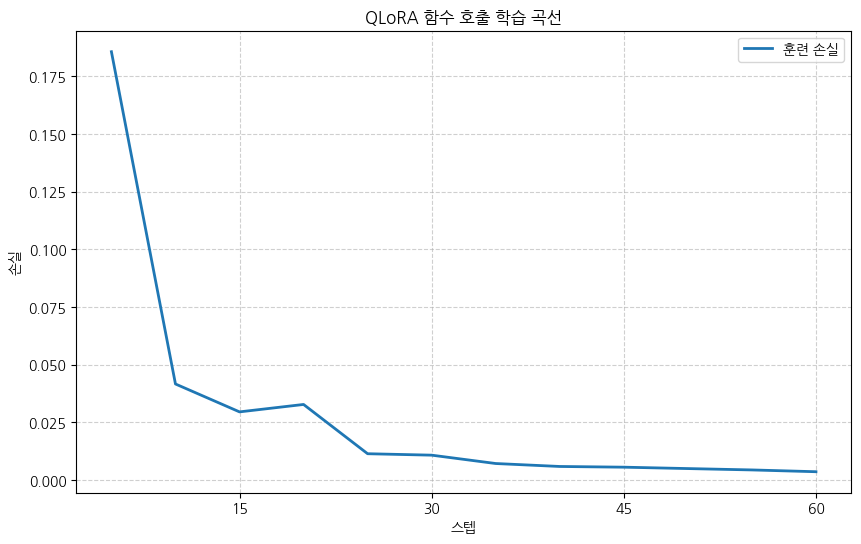

In [13]:
# 참고 - log_history에서 훈련 손실을 뽑아 학습 곡선을 그린다 (§7.7)
train_curve = [(rec['step'], rec['loss'])
               for rec in trainer.state.log_history if 'loss' in rec]

viz.plot_history(
    train_curve, label='훈련 손실',
    title='QLoRA 함수 호출 학습 곡선', x_label='스텝', y_label='손실',
)

## [코드 12-17] LoRA 어댑터 계층 활성화/비활성화별 모델 평가

`model.disable_adapter()` 컨텍스트에서는 어댑터가 비활성화되어 미세 조정 전
모델의 답을 얻는다. 21건의 평가 데이터셋으로 OFF/ON을 비교한다.


In [16]:
# 코드 12-17 - LoRA 어댑터 계층 활성화/비활성화별 모델 평가
model.eval()

# 어댑터 계층 비활성화 (미세 조정 전 양자화 모델 추론)
print('### 어댑터 계층 비활성화')
with model.disable_adapter():
    off_rows, off_stats = evaluate(model, eval_samples, '어댑터 OFF')

# 어댑터 계층 활성화 (QLoRA 미세 조정 적용 양자화 모델 추론)
print('### 어댑터 계층 활성화')
on_rows, on_stats = evaluate(model, eval_samples, '어댑터 ON')


### 어댑터 계층 비활성화
[어댑터 OFF] n=21 JSON parse 21/21, function 18/21, args 완전일치 6/21
### 어댑터 계층 활성화
[어댑터 ON] n=21 JSON parse 21/21, function 21/21, args 완전일치 18/21


### 참고 - 실제 출력 결과 비교 (앞 3건)

베이스 모델이 어떤 식으로 실패하고 어댑터가 그 행동을 어떻게 교정하는지 직접
비교한다. 본문에서 다룬 "글피→2024-03-16" 정규화나 "뉴진스 노래→New Junk City"
환각이 어댑터 ON에서 교정되는 것을 볼 수 있다.


In [15]:
# 참고 - 앞 3건을 OFF vs ON 으로 나란히 출력
for i in range(3):
    user, gold, _, _ = on_rows[i]
    print(f'\nUSER : {user}')
    print(f'GOLD : {gold}')
    print(f'OFF  : {off_rows[i][2][:200]}')
    print(f'ON   : {on_rows[i][2][:200]}')



USER : 글피 오전 9시부터 독서 모임 잡아 둘래?
GOLD : {"function": "create_event", "args": {"date": "글피", "time": "오전 9시", "title": "독서 모임"}}
OFF  : {"function": "create_event", "args": {"date": "2024-06-19", "time": "09:00", "title": "독서 모임"}}
ON   : {"function": "create_event", "args": {"date": "글피", "time": "오전 9시", "title": "독서 모임"}}

USER : 준호에게 "자료 받았습니다 감사합니다" 라고 카톡 좀
GOLD : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}
OFF  : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}
ON   : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}

USER : 오늘 제주 기온 알려 주실래요?
GOLD : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}
OFF  : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}
ON   : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}
